In [5]:
import pandas as pd

In [6]:
df = pd.read_csv("Dataset.csv")

In [7]:
df.head()

,product_name,product_price,Rate,Review,Summary,Sentiment
0,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,5,super!,great cooler excellent air flow and for this p...,positive
1,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,5,awesome,best budget 2 fit cooler nice cooling,positive
2,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,3,fair,the quality is good but the power of air is de...,positive
3,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,1,useless product,very bad product its a only a fan,negative
4,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,3,fair,ok ok product,neutral


In [8]:
df.shape

(308, 6)

In [9]:
df.columns

Index(['product_name', 'product_price', 'Rate', 'Review', 'Summary',
       'Sentiment'],
      dtype='object')

In [10]:
df.dtypes

,0
product_name,object
product_price,int64
Rate,int64
Review,object
Summary,object
Sentiment,object


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 308 entries, 0 to 307
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   product_name   308 non-null    object
 1   product_price  308 non-null    int64 
 2   Rate           308 non-null    int64 
 3   Review         308 non-null    object
 4   Summary        308 non-null    object
 5   Sentiment      308 non-null    object
dtypes: int64(2), object(4)
memory usage: 14.6+ KB


In [12]:
df["Sentiment"].value_counts()

,count
Sentiment,
positive,252
negative,47
neutral,9


In [13]:
df["Review"].head()

,Review
0,super!
1,awesome
2,fair
3,useless product
4,fair


In [14]:
df[["Review", "Sentiment"]].head(10)

,Review,Sentiment
0,super!,positive
1,awesome,positive
2,fair,positive
3,useless product,negative
4,fair,neutral
5,awesome,positive
6,highly recommended,positive
7,nice,positive
8,unsatisfactory,negative
9,worth the money,positive


In [15]:
df.head()

,product_name,product_price,Rate,Review,Summary,Sentiment
0,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,5,super!,great cooler excellent air flow and for this p...,positive
1,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,5,awesome,best budget 2 fit cooler nice cooling,positive
2,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,3,fair,the quality is good but the power of air is de...,positive
3,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,1,useless product,very bad product its a only a fan,negative
4,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,3,fair,ok ok product,neutral


In [16]:
df.isnull().sum()

,0
product_name,0
product_price,0
Rate,0
Review,0
Summary,0
Sentiment,0


In [17]:
df.duplicated().sum()

np.int64(4)

In [18]:
df = df.drop_duplicates()

In [19]:
df.duplicated().sum()

np.int64(0)

In [20]:
df.dtypes

,0
product_name,object
product_price,int64
Rate,int64
Review,object
Summary,object
Sentiment,object


In [21]:
df["Review"].isnull().sum()

np.int64(0)

In [22]:
df = df.dropna(subset=["Review"])

In [23]:
df["Cleaned_Review"] = df["Review"].str.lower()

In [24]:

import re

In [25]:
def clean_text(text):
    text = re.sub(r'[^a-zA-Z\s]', '', str(text))
    return text

In [26]:
df["Cleaned_Review"] = df["Cleaned_Review"].apply(clean_text)

In [27]:
df["Cleaned_Review"] = df["Cleaned_Review"].str.replace(r'\s+', ' ', regex=True).str.strip()

In [28]:
df[["Review", "Cleaned_Review"]].head(10)


,Review,Cleaned_Review
0,super!,super
1,awesome,awesome
2,fair,fair
3,useless product,useless product
4,fair,fair
5,awesome,awesome
6,highly recommended,highly recommended
7,nice,nice
8,unsatisfactory,unsatisfactory
9,worth the money,worth the money


In [29]:
df["Sentiment"] = df["Sentiment"].str.lower().str.strip()

In [30]:
df["Sentiment"].value_counts()

,count
Sentiment,
positive,248
negative,47
neutral,9


In [31]:
df.shape

(304, 7)

In [32]:
df.to_csv("cleaned_product_reviews.csv", index=False)

In [33]:
import os

os.path.exists("cleaned_product_reviews.csv")

True

In [34]:
import pandas as pd

In [35]:
df = pd.read_csv("cleaned_product_reviews.csv")

In [36]:
df.head()

,product_name,product_price,Rate,Review,Summary,Sentiment,Cleaned_Review
0,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,5,super!,great cooler excellent air flow and for this p...,positive,super
1,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,5,awesome,best budget 2 fit cooler nice cooling,positive,awesome
2,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,3,fair,the quality is good but the power of air is de...,positive,fair
3,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,1,useless product,very bad product its a only a fan,negative,useless product
4,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,3,fair,ok ok product,neutral,fair


In [37]:
df.select_dtypes(include="number").columns

Index(['product_price', 'Rate'], dtype='object')

In [38]:
df[["product_price", "Rate"]].mean()

,0
product_price,7952.947368
Rate,4.023026


In [39]:
df[["product_price", "Rate"]].median()

,0
product_price,7999.0
Rate,5.0


In [40]:
df[["product_price", "Rate"]].mode()

,product_price,Rate
0,7999,5


In [41]:
df[["product_price", "Rate"]].min()

,0
product_price,3999
Rate,1


In [42]:
df[["product_price", "Rate"]].max()

,0
product_price,8999
Rate,5


In [43]:
df[["product_price", "Rate"]].max() - df[["product_price", "Rate"]].min()

,0
product_price,5000
Rate,4


In [44]:
df[["product_price", "Rate"]].var()

,0
product_price,611733.541775
Rate,1.850953


In [45]:
df[["product_price", "Rate"]].std()

,0
product_price,782.133967
Rate,1.360497


In [46]:
df[["product_price", "Rate"]].describe()

,product_price,Rate
count,304.000000,304.000000
mean,7952.947368,4.023026
std,782.133967,1.360497
min,3999.000000,1.000000
25%,7999.000000,4.000000
50%,7999.000000,5.000000
75%,7999.000000,5.000000
max,8999.000000,5.000000


In [47]:
df["Sentiment"].value_counts()

,count
Sentiment,
positive,248
negative,47
neutral,9


In [48]:
df["Sentiment"].value_counts(normalize=True) * 100

,proportion
Sentiment,
positive,81.578947
negative,15.460526
neutral,2.960526


In [49]:
df.groupby("Sentiment")["Rate"].mean()

,Rate
Sentiment,
negative,1.659574
neutral,2.777778
positive,4.516129


In [50]:
df.groupby("Sentiment")["product_price"].mean()

,product_price
Sentiment,
negative,7850.063830
neutral,7554.555556
positive,7986.903226


In [51]:
print("Mean:")
print(df[["product_price", "Rate"]].mean())

print("\nMedian:")
print(df[["product_price", "Rate"]].median())

print("\nMode:")
print(df[["product_price", "Rate"]].mode())

print("\nRange:")
print(df[["product_price", "Rate"]].max() - df[["product_price", "Rate"]].min())

print("\nVariance:")
print(df[["product_price", "Rate"]].var())

print("\nStandard Deviation:")
print(df[["product_price", "Rate"]].std())

Mean:
product_price    7952.947368
Rate                4.023026
dtype: float64

Median:
product_price    7999.0
Rate                5.0
dtype: float64

Mode:
   product_price  Rate
0           7999     5

Range:
product_price    5000
Rate                4
dtype: int64

Variance:
product_price    611733.541775
Rate                  1.850953
dtype: float64

Standard Deviation:
product_price    782.133967
Rate               1.360497
dtype: float64


In [52]:
import pandas as pd
import matplotlib.pyplot as plt

In [53]:
df = pd.read_csv("cleaned_product_reviews.csv")

In [54]:
df.head()

,product_name,product_price,Rate,Review,Summary,Sentiment,Cleaned_Review
0,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,5,super!,great cooler excellent air flow and for this p...,positive,super
1,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,5,awesome,best budget 2 fit cooler nice cooling,positive,awesome
2,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,3,fair,the quality is good but the power of air is de...,positive,fair
3,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,1,useless product,very bad product its a only a fan,negative,useless product
4,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,3,fair,ok ok product,neutral,fair


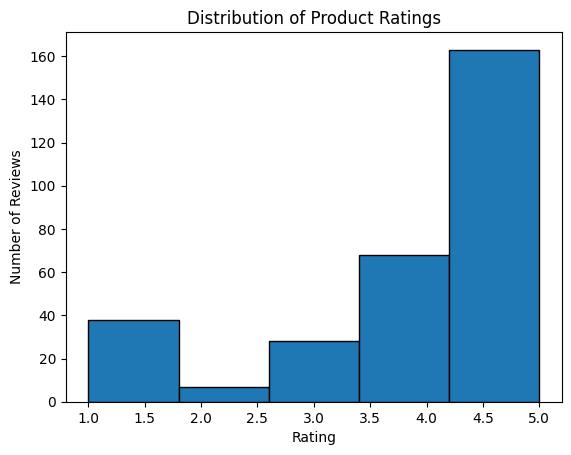

In [55]:
plt.hist(df["Rate"], bins=5, edgecolor="black")

plt.title("Distribution of Product Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Reviews")

plt.show()

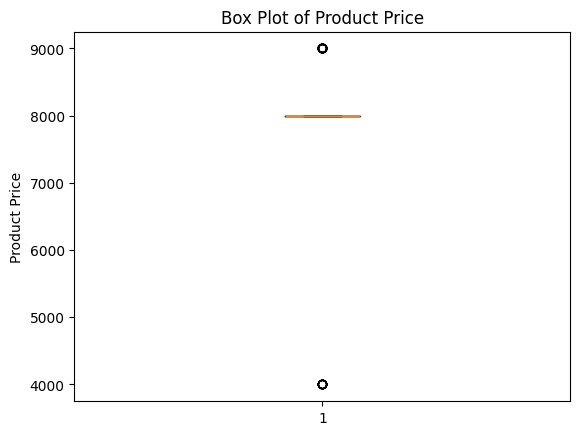

In [56]:
plt.boxplot(df["product_price"])

plt.title("Box Plot of Product Price")
plt.ylabel("Product Price")

plt.show()

In [57]:
sentiment_count = df["Sentiment"].value_counts()

sentiment_count

,count
Sentiment,
positive,248
negative,47
neutral,9


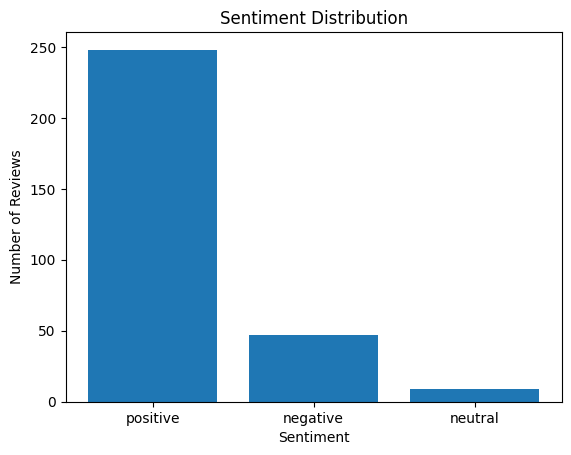

In [58]:
plt.bar(sentiment_count.index, sentiment_count.values)

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")

plt.show()

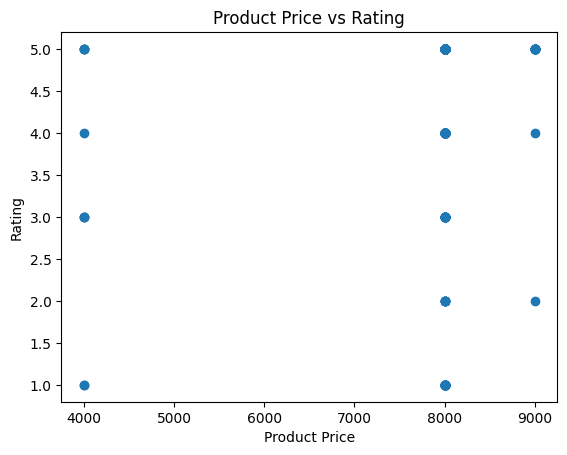

In [59]:
plt.scatter(df["product_price"], df["Rate"])

plt.title("Product Price vs Rating")
plt.xlabel("Product Price")
plt.ylabel("Rating")

plt.show()

In [60]:
average_rating = df.groupby("Sentiment")["Rate"].mean()

average_rating

,Rate
Sentiment,
negative,1.659574
neutral,2.777778
positive,4.516129


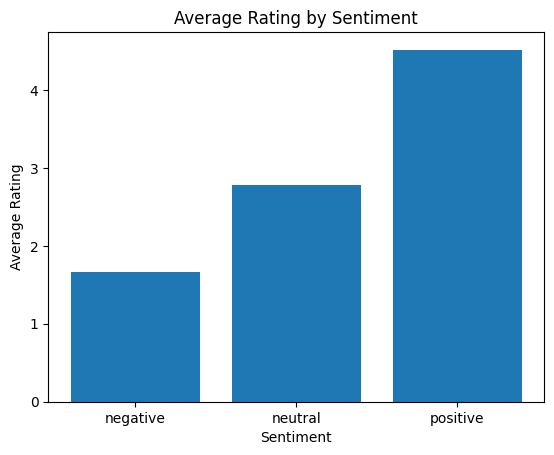

In [61]:
plt.bar(average_rating.index, average_rating.values)

plt.title("Average Rating by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Average Rating")

plt.show()

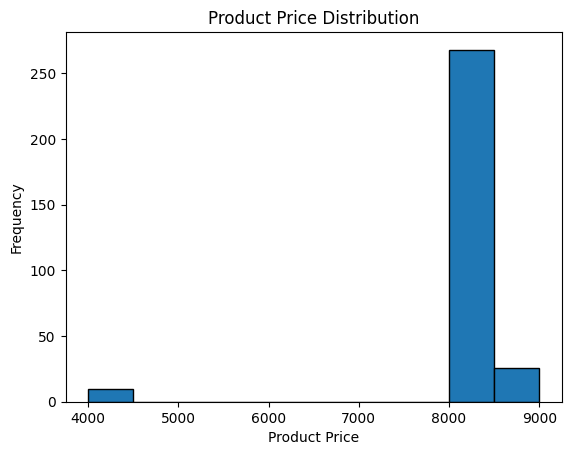

In [62]:
plt.hist(df["product_price"], bins=10, edgecolor="black")

plt.title("Product Price Distribution")
plt.xlabel("Product Price")
plt.ylabel("Frequency")

plt.show()

In [63]:
print("Total Reviews:", len(df))

print("\nSentiment Distribution:")
print(df["Sentiment"].value_counts())

print("\nAverage Rating:")
print(df["Rate"].mean())

Total Reviews: 304

Sentiment Distribution:
Sentiment
positive    248
negative     47
neutral       9
Name: count, dtype: int64

Average Rating:
4.0230263157894735


In [64]:
import pandas as pd

In [65]:
df = pd.read_csv("cleaned_product_reviews.csv")

In [66]:
df.head()

,product_name,product_price,Rate,Review,Summary,Sentiment,Cleaned_Review
0,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,5,super!,great cooler excellent air flow and for this p...,positive,super
1,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,5,awesome,best budget 2 fit cooler nice cooling,positive,awesome
2,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,3,fair,the quality is good but the power of air is de...,positive,fair
3,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,1,useless product,very bad product its a only a fan,negative,useless product
4,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,3,fair,ok ok product,neutral,fair


In [67]:
X = df["Cleaned_Review"]
y = df["Sentiment"]

In [68]:
from sklearn.model_selection import train_test_split

In [69]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [70]:
print("Training data:", len(X_train))
print("Testing data:", len(X_test))

Training data: 243
Testing data: 61


In [71]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [72]:
vectorizer = TfidfVectorizer()

In [73]:
X_train_tfidf = vectorizer.fit_transform(X_train)

In [74]:
X_test_tfidf = vectorizer.transform(X_test)

In [75]:
X_train_tfidf.shape

(243, 75)

In [76]:
from sklearn.naive_bayes import MultinomialNB

In [77]:
model = MultinomialNB()

In [78]:
model.fit(X_train_tfidf, y_train)

MultinomialNB()

In [79]:
y_pred = model.predict(X_test_tfidf)

In [80]:
print(y_pred[:10])

['positive' 'positive' 'positive' 'positive' 'positive' 'positive'
 'positive' 'positive' 'positive' 'positive']


In [81]:
result = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

result.head(10)

,Actual,Predicted
180,positive,positive
154,positive,positive
111,positive,positive
247,positive,positive
60,positive,positive
9,positive,positive
119,positive,positive
157,positive,positive
167,positive,positive
33,positive,positive


In [82]:
from sklearn.metrics import accuracy_score

In [83]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8524590163934426


In [84]:
print("Accuracy: {:.2f}%".format(accuracy * 100))

Accuracy: 85.25%


In [85]:
from sklearn.metrics import classification_report

In [86]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    negative       0.80      0.36      0.50        11
     neutral       0.00      0.00      0.00         1
    positive       0.86      0.98      0.91        49

    accuracy                           0.85        61
   macro avg       0.55      0.45      0.47        61
weighted avg       0.83      0.85      0.82        61



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [87]:
from sklearn.metrics import confusion_matrix

In [88]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[ 4  0  7]
 [ 0  0  1]
 [ 1  0 48]]


In [89]:
review = ["This product is very good and I really loved it"]

In [90]:
review_tfidf = vectorizer.transform(review)

In [91]:

prediction = model.predict(review_tfidf)

print("Predicted Sentiment:", prediction[0])

Predicted Sentiment: positive


In [92]:

review = ["The product quality is very bad and disappointing"]

review_tfidf = vectorizer.transform(review)

prediction = model.predict(review_tfidf)

print("Predicted Sentiment:", prediction[0])

Predicted Sentiment: positive


In [94]:
import pandas as pd
import numpy as np

In [95]:
df = pd.read_csv("cleaned_product_reviews.csv")

df.head()

,product_name,product_price,Rate,Review,Summary,Sentiment,Cleaned_Review
0,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,5,super!,great cooler excellent air flow and for this p...,positive,super
1,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,5,awesome,best budget 2 fit cooler nice cooling,positive,awesome
2,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,3,fair,the quality is good but the power of air is de...,positive,fair
3,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,1,useless product,very bad product its a only a fan,negative,useless product
4,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,3,fair,ok ok product,neutral,fair


In [96]:
X = df["Cleaned_Review"]
y = df["Sentiment"]

In [97]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [98]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer()

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

In [99]:
print("Training Shape:", X_train_tfidf.shape)
print("Testing Shape:", X_test_tfidf.shape)

Training Shape: (243, 77)
Testing Shape: (61, 77)


In [100]:
from sklearn.linear_model import LogisticRegression

In [101]:
lr_model = LogisticRegression(max_iter=1000)

In [102]:
lr_model.fit(X_train_tfidf, y_train)

LogisticRegression(max_iter=1000)

In [103]:
lr_pred = lr_model.predict(X_test_tfidf)

In [104]:
from sklearn.metrics import accuracy_score, precision_score

In [ ]:
lr_accuracy = accuracy_score(y_test, lr_pred)

print("Logistic Regression Accuracy:", lr_accuracy)
print("Accuracy Percentage: {:.2f}%".format(lr_accuracy * 100))

In [105]:
lr_precision = precision_score(
    y_test,
    lr_pred,
    average="weighted",
    zero_division=0
)

print("Logistic Regression Precision:", lr_precision)
print("Precision Percentage: {:.2f}%".format(lr_precision * 100))

Logistic Regression Precision: 0.7908422837761446
Precision Percentage: 79.08%


In [106]:
from sklearn.neighbors import KNeighborsClassifier

In [107]:
knn_model = KNeighborsClassifier(n_neighbors=5)

In [108]:
knn_model.fit(X_train_tfidf, y_train)

KNeighborsClassifier()

In [109]:
knn_pred = knn_model.predict(X_test_tfidf)

In [114]:
knn_accuracy = accuracy_score(y_test, knn_pred)

print("KNN Accuracy:", knn_accuracy)
print("Accuracy Percentage: {:.2f}%".format(knn_accuracy * 100))

KNN Accuracy: 0.8524590163934426
Accuracy Percentage: 85.25%


In [115]:
knn_precision = precision_score(
    y_test,
    knn_pred,
    average="weighted",
    zero_division=0
)

print("KNN Precision:", knn_precision)
print("Precision Percentage: {:.2f}%".format(knn_precision * 100))

KNN Precision: 0.8421783828841345
Precision Percentage: 84.22%


In [118]:
from sklearn.metrics import accuracy_score, precision_score

lr_accuracy = accuracy_score(y_test, lr_pred)
lr_precision = precision_score(y_test, lr_pred, average="weighted", zero_division=0)

knn_accuracy = accuracy_score(y_test, knn_pred)
knn_precision = precision_score(y_test, knn_pred, average="weighted", zero_division=0)

In [119]:
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "KNN"],
    "Accuracy": [lr_accuracy, knn_accuracy],
    "Precision": [lr_precision, knn_precision]
})

comparison

,Model,Accuracy,Precision
0,Logistic Regression,0.836066,0.790842
1,KNN,0.852459,0.842178


In [120]:
if lr_accuracy >= knn_accuracy:
    final_model = lr_model
    final_pred = lr_pred
    print("Final Model: Logistic Regression")
else:
    final_model = knn_model
    final_pred = knn_pred
    print("Final Model: KNN")

Final Model: KNN


In [121]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    final_pred,
    zero_division=0
))

              precision    recall  f1-score   support

    negative       1.00      0.22      0.36         9
     neutral       0.00      0.00      0.00         2
    positive       0.85      1.00      0.92        50

    accuracy                           0.85        61
   macro avg       0.62      0.41      0.43        61
weighted avg       0.84      0.85      0.81        61



In [122]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, final_pred)

print(cm)

[[ 2  0  7]
 [ 0  0  2]
 [ 0  0 50]]


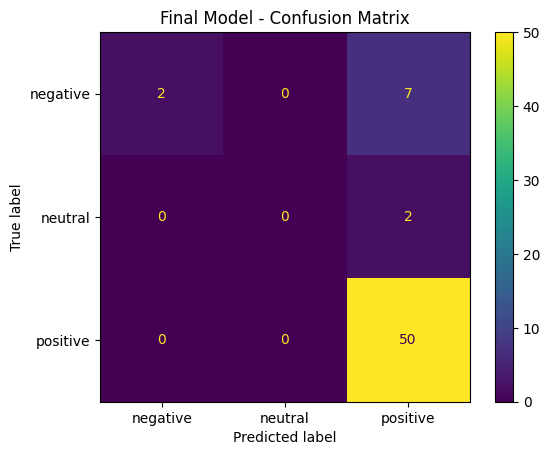

In [123]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    final_pred
)

plt.title("Final Model - Confusion Matrix")
plt.show()

In [124]:
new_review = ["This product is amazing and worth the money"]

In [125]:
new_review_tfidf = vectorizer.transform(new_review)

In [126]:
prediction = final_model.predict(new_review_tfidf)

print("Predicted Sentiment:", prediction[0])

Predicted Sentiment: positive


In [127]:
new_review = ["Very bad product and waste of money"]

new_review_tfidf = vectorizer.transform(new_review)

prediction = final_model.predict(new_review_tfidf)

print("Predicted Sentiment:", prediction[0])

Predicted Sentiment: positive


In [128]:
import pickle

In [129]:
with open("sentiment_model.pkl", "wb") as file:
    pickle.dump(final_model, file)

In [130]:
with open("tfidf_vectorizer.pkl", "wb") as file:
    pickle.dump(vectorizer, file)